# ASTR 223 Final Project: Gaussian Process Model (xHRs)

Some source code taken from: https://num.pyro.ai/en/stable/tutorials/hsgp_nd_example.html

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.typing import NDArray
import gc

## modeling libraries
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, log_loss, brier_score_loss, accuracy_score
from sklearn.calibration import calibration_curve
from sklearn import set_config
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import os
os.environ["SCIPY_ARRAY_API"] = "1" ## tells scipy it can use JAX arrays
from scipy.stats import binned_statistic_2d

from optax import linear_onecycle_schedule

import jax
from jax import random
import jax.numpy as jnp
import jax.nn

import numpyro
from numpyro import distributions as dist
from numpyro.infer import Predictive, log_likelihood
from numpyro.infer.elbo import Trace_ELBO
from numpyro.optim import Adam
from numpyro.infer.svi import SVI
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_median
from numpyro.contrib.hsgp.approximation import hsgp_squared_exponential
from numpyro.contrib.hsgp.approximation import hsgp_matern

import arviz as az

blue_color = '#005A9C'
red_color = '#EF3E42'
color_palette = {0: blue_color, 1: red_color}

In [3]:
seed = 42
key = jax.random.key(seed)
numpyro.set_host_device_count(6)
jax.config.update("jax_enable_x64", True) ## makes the arrays a little more precise
set_config(array_api_dispatch=True) ## allows the use of JAX arrays within scikit functions

In [4]:
batted_ball_events = pd.read_parquet('data/batted_ball_events.parquet')
player_primary_pos = pd.read_parquet('data/player_primary_pos.parquet')

In [5]:
X = jnp.asarray(batted_ball_events[['launch_speed', 'launch_angle']].to_numpy(dtype=float))
y = jnp.asarray(batted_ball_events['is_HR'].to_numpy(dtype=int))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

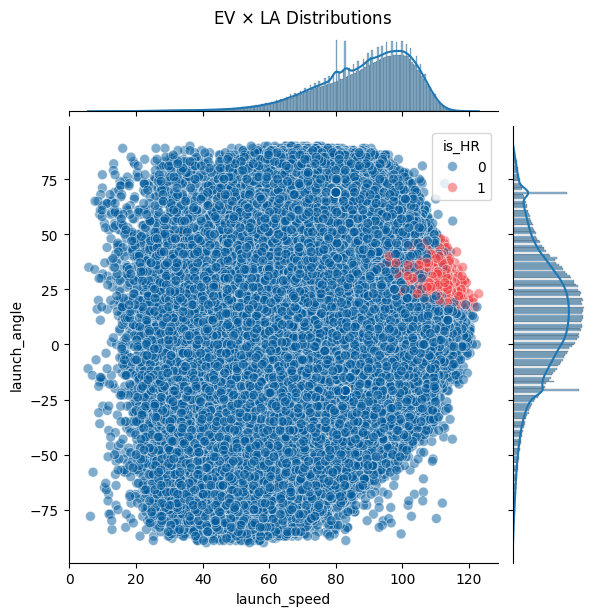

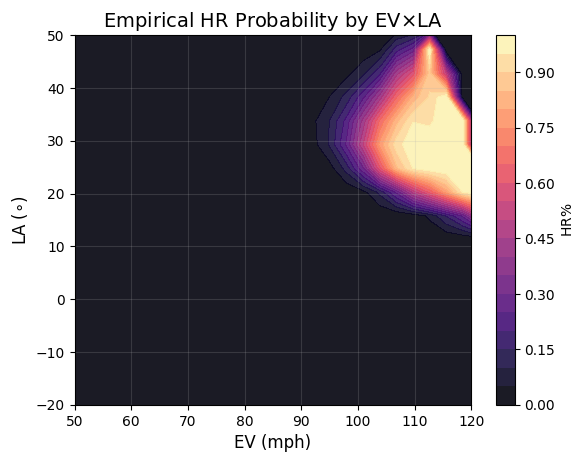

In [6]:
# plots the surface of EV x LA of where HRs tend to occur within this surface

X_train_df = pd.DataFrame(X_train, columns=["launch_speed", "launch_angle"])
X_train_df["is_HR"] = y_train
joint_grid = sns.JointGrid(data=X_train_df, x="launch_speed", y="launch_angle")
sns.scatterplot(data=X_train_df, x="launch_speed", y="launch_angle", hue="is_HR", palette=color_palette, alpha=0.5, s=50, ax=joint_grid.ax_joint)
sns.histplot(data=X_train_df, x="launch_speed", kde=True, ax=joint_grid.ax_marg_x)
sns.histplot(data=X_train_df, y="launch_angle", kde=True, ax=joint_grid.ax_marg_y)
joint_grid.ax_joint.legend(title="is_HR", loc="upper right")
plt.suptitle(r"EV $\times$ LA Distributions", y=1.02)
plt.show()

def empirical_hr_surface(X, y, bins=40):
    """
    Creates the feature surface and the empirical HR%
    """
    ## bins the EV x LA continuous surface
    bin_means, x_edges, y_edges, _ = binned_statistic_2d(X[:, 0], X[:, 1], y, statistic='mean', bins=bins,)
    
    ## creates the meshgrid of EV x LA
    ev_centers = (x_edges[:-1] + x_edges[1:]) / 2
    la_centers = (y_edges[:-1] + y_edges[1:]) / 2
    EV_grid, LA_grid = np.meshgrid(ev_centers, la_centers)

    ## creates grid for HR%
    HR_grid = bin_means.T ## matches the dims of the EV x LA meshgrid
    HR_grid = np.nan_to_num(HR_grid, nan=0.0) ## fills any missing HR% for certain bins with 0% HR%

    fig, ax = plt.subplots()    
    contour = ax.contourf(EV_grid, LA_grid, HR_grid, levels=20, cmap='magma', alpha=0.9)
    ax.set_xlim(50, 120)
    ax.set_ylim(-20, 50)
    ax.set_xlabel('EV (mph)', fontsize=12)
    ax.set_ylabel(r'LA ($\circ$)', fontsize=12)
    ax.set_title(r'Empirical HR Probability by EV$\times$LA', fontsize=14)
    fig.colorbar(contour, ax=ax, label=r'HR$\%$')
    plt.grid(alpha=0.2)
    plt.show()

empirical_hr_surface(X_train, y_train)

In [7]:
X_train_mean = jnp.mean(X_train, axis=0)
X_train_std = jnp.std(X_train, axis=0)
## standardizing the continous features --> ensures numerical stability
X_train_scaled = (X_train - X_train_mean) / X_train_std
## standardizing test too based on the means, stds computed from the training set
X_test_scaled = (X_test - X_train_mean) / X_train_std

## used to calculate the boundary limits of the HSGP
L1 = abs(X_train_scaled[:, 0].max())
L2 = abs(X_train_scaled[:, 1].max())

## HSGP Model

Trying out two different kernels: Matern 5/2, and Squared Exponential 

In [8]:
empirical_hr_prob = batted_ball_events['is_HR'].value_counts(normalize=True).iloc[1]
log_odds_baseline = np.log(empirical_hr_prob / (1 - empirical_hr_prob))

In [ ]:
def fit_svi(seed: int, model: callable, guide: callable, num_steps: int = 5_000, peak_lr: float = 0.01, **model_kwargs,):
    """
    Trains the HSGP with SVI --> approximates the posteriors with optimization rather than the exact posterior (i.e., MCMC)
    SVI uses stochastic optimization: mini batches + stochastic gradient ascent
    Source: https://www.geeksforgeeks.org/data-science/stochastic-variational-inference-svi/
    """
    lr_scheduler = linear_onecycle_schedule(num_steps, peak_lr) ## maps out the lr at steps 1, 2,..., 5000
    svi = SVI(model, guide, Adam(lr_scheduler), Trace_ELBO()) ## Adam updates the weights inside the guide 
    return svi.run(random.PRNGKey(seed), num_steps, progress_bar=False, **model_kwargs)

def posterior_predictive_svi(seed: int, model: callable, guide: callable, params: dict, num_samples: int = 2_000, **model_kwargs,) -> dict[str, jax.Array]:
    """
    Generates new data based on the model with the best estimated params (the posterior predictive distribution)
    """
    predictive = Predictive(model, guide=guide, params=params, num_samples=num_samples)
    return predictive(random.PRNGKey(seed), **model_kwargs)

@jax.tree_util.register_pytree_node_class
class HSGPModel:
    def __init__(self, m: list[int], L: list[float]):
        self.m = m ## num of basis funcs
        self.L = L ## boundary limits

    def model(self, X: jax.Array, y: jax.Array | None = None):
        amplitude = numpyro.sample("amplitude", dist.LogNormal(0, 1)) ## A ~ LogNormal(0, 1) --> 0 is in the log-odds, so 50%
        length = numpyro.sample("lengthscale", dist.Exponential(jnp.ones(2))) ## l ~ Exponential([1, 1]) --> a length scale for each feature in R^2
        f_centered = hsgp_squared_exponential(X, alpha=amplitude, length=length, ell=self.L, m=self.m)
        f = numpyro.deterministic("f_star", f_centered + log_odds_baseline) ## we're setting the m(x) at -3 (in log odds) ≈ 0.0474 HR%
        site = "y" if y is not None else "y_test"
        numpyro.sample(site, dist.Bernoulli(logits=f), obs=y) ## our likelihood function

    def tree_flatten(self):
            children = ()  
            aux_data = (self.L, self.m) 
            return (children, aux_data)
    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)
    
@jax.tree_util.register_pytree_node_class
class HSGP_matern52_Model:
    def __init__(self, m: list[int], L: list[float]):
        self.m = m
        self.L = L

    def model(self, X: jax.Array, y: jax.Array | None = None):
        amplitude = numpyro.sample("amplitude", dist.LogNormal(0, 1))
        length = numpyro.sample("lengthscale", dist.Exponential(jnp.ones(2)))
        f_centered = hsgp_matern(X, alpha=amplitude, length=length, ell=self.L, m=self.m, nu=2.5) ## nu = 2.5 makes it matern 5/2 kernel
        f = numpyro.deterministic("f_star", f_centered + log_odds_baseline)
        site = "y" if y is not None else "y_test"
        numpyro.sample(site, dist.Bernoulli(logits=f), obs=y) ## our likelihood function

    def tree_flatten(self):
            children = ()  
            aux_data = (self.L, self.m) 
            return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)

In [ ]:
def test_results(y_test: jax.Array, probs: jax.Array, preds: jax.Array):
    """
    Outputs the model's test results
    """
    y_test_np = np.array(y_test)
    probs_np = np.array(probs)
    preds_np = np.array(preds)

    acc = accuracy_score(y_test_np, preds_np)
    prec = precision_score(y_test_np, preds_np, zero_division=0)
    recall = recall_score(y_test_np, preds_np, zero_division=0)
    f1 = f1_score(y_test_np, preds_np, zero_division=0)
    roc_auc = roc_auc_score(y_test_np, probs_np)
    ll = log_loss(y_test_np, probs_np)
    brier = brier_score_loss(y_test_np, probs_np)

    print(f"Test Accuracy: {acc}")
    print(f"Test Precision: {prec}")
    print(f"Test Recall: {recall}")
    print(f"Test F1: {f1}")
    print(f"Test ROC-AUC: {roc_auc}")
    print(f"Test Log-Loss: {ll}")
    print(f"Test Brier Score: {brier}")

def plot_bayesian_calibration(y_test: jax.Array, posterior_f_star: jax.Array, n_bins: int = 10, n_draws: int = 100):
    """
    Plots a Bayesian calibration curve with uncertainty bands and a prediction histogram
    """
    y_true_np = np.array(y_test)
    ## calculates the mean probs for the main line and the histogram
    mean_f_star = posterior_f_star.mean(axis=0)
    mean_probs = np.array(jax.nn.sigmoid(mean_f_star))

    fig, ax1 = plt.subplots()
    ## randomly selects a subset of posterior draws
    draw_indices = np.random.choice(posterior_f_star.shape[0], size=n_draws, replace=False)
    for idx in draw_indices:
        ## gets the probs for each sample from this draw
        sample_probs = np.array(jax.nn.sigmoid(posterior_f_star[idx]))
        ## calculates the calibration for this draw
        emp_pct, pred_pct = calibration_curve(y_true_np, sample_probs, n_bins=n_bins, strategy='uniform') ## uniform keeps the x-axis aligned
        ax1.plot(pred_pct, emp_pct, color=blue_color, alpha=0.05)

    ## plots the calibration curve
    emp_mean, pred_mean = calibration_curve(y_true_np, mean_probs, n_bins=n_bins, strategy='uniform')
    ax1.plot(pred_mean, emp_mean, marker='o', linewidth=2, color=blue_color, label='Posterior Mean')
    ax1.plot([0, 1], [0, 1], linestyle='--', color=red_color, label='Perfect Calibration')
    ax1.set_xlim([-0.05, 1.05])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_xlabel('Predicted Probability (HR%)')
    ax1.set_ylabel('Empirical Probability (HR%)')
    ax1.set_title('HSGP Predicted vs. Empirical HR%')
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    ## histogram of # of BIPs at each prob level (homers are uncommon, so the density at the prob levels of 0.8/0.9 should be small)
    ax2 = ax1.twinx()
    ax2.hist(mean_probs, bins=50, alpha=0.3, color='gray', density=False)
    ax2.set_ylabel('Count of Batted Balls', color='k')
    ax2.tick_params(axis='y', labelcolor='k')
    ax2.set_ylim([0, len(y_test)]) 
    plt.show()

def plot_decision_boundary(seed: int, model: callable, guide: callable, params: dict, X_train_mean: jax.Array, X_train_std: jax.Array):
    """
    Creates a contour plot of the GP probs across an EV X LA grid
    """
    ev_linspace = jnp.linspace(50, 120, 50)
    la_linspace = jnp.linspace(-20, 50, 50)
    EV_grid, LA_grid = jnp.meshgrid(ev_linspace, la_linspace)

    ## flattens the grid into a list of [EV, LA] coords
    grid_points = jnp.c_[EV_grid.ravel(), LA_grid.ravel()]

    ## standardizes the grid points
    grid_points_scaled = (grid_points - X_train_mean) / X_train_std

    ## generates the predictions on the scaled grid
    grid_predictive = posterior_predictive_svi(seed, model, guide, params, X=grid_points_scaled, num_samples=200)
    
    ## calculates the grid HR probs
    grid_mean_f = grid_predictive["f_star"].mean(axis=0) ## it uses the posterior mean of each draw's samples
    grid_probs = jax.nn.sigmoid(grid_mean_f) ## log-odds -> [0, 1]
    
    ## reshapes the probs back into the 2D grid shape
    HR_grid_pred = grid_probs.reshape(EV_grid.shape)

    fig, ax = plt.subplots()    
    contour = ax.contourf(EV_grid, LA_grid, HR_grid_pred, levels=20, cmap='magma', alpha=0.9)
    ax.set_xlim(50, 120)
    ax.set_ylim(-20, 50)
    ax.set_xlabel('EV (mph)', fontsize=12)
    ax.set_ylabel(r'LA ($\circ$)', fontsize=12)
    ax.set_title(r'HSGP Predicted HR Probability by EV$\times$LA', fontsize=14)
    fig.colorbar(contour, ax=ax, label=r'xHR$\%$')
    plt.grid(alpha=0.2)
    plt.show()

--HSGPModel Prior Predictive Check--


W0312 20:48:25.808653  190000 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


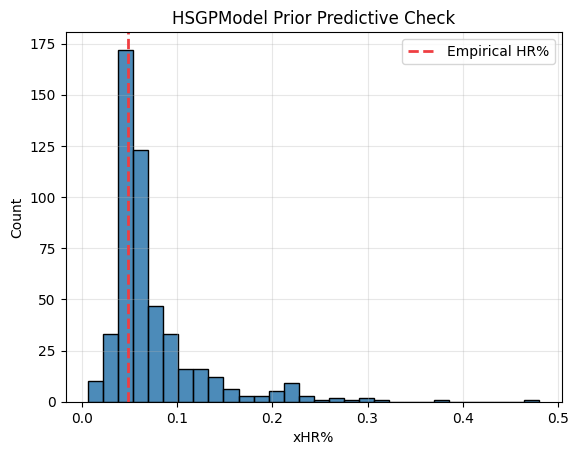

--HSGP_matern52_Model Prior Predictive Check--


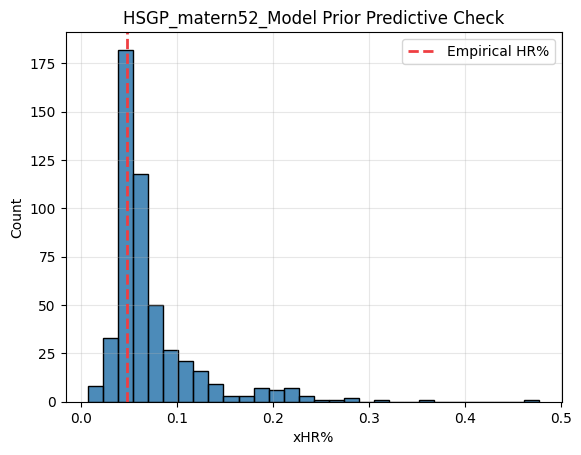

In [11]:
# prior predictive checks

for gp in [HSGPModel, HSGP_matern52_Model]:
    print(f'--{gp.__name__} Prior Predictive Check--')
    prior_check = gp(m=[15, 15], L=[L1 * 1.25, L2 * 1.25])
    ## no trained guide or parameters
    prior_predictive = Predictive(prior_check.model, num_samples=500)
    prior_samples = prior_predictive(random.PRNGKey(seed), X=X_train_scaled)
    prior_probs = jax.nn.sigmoid(prior_samples["f_star"])

    ## average HR% predicted in each of the 500 sims
    mean_prior_predictions = prior_probs.mean(axis=1) 

    plt.figure()
    sns.histplot(mean_prior_predictions, bins=30, color=blue_color, edgecolor='k', alpha=0.7)
    plt.axvline(x=0.048, color=red_color, linestyle='--', linewidth=2, label='Empirical HR%')
    plt.title(f"{gp.__name__} Prior Predictive Check")
    plt.xlabel("xHR%")
    # plt.xlim([0.0, 0.20])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

--Training HSGPModel--
posterior predictive distrib generated
Test Accuracy: 0.972693616502433
Test Precision: 0.7459016393442623
Test Recall: 0.640318986747977
Test F1: 0.6890894175553732
Test ROC-AUC: 0.9836179494503857
Test Log-Loss: 0.06648704862497902
Test Brier Score: 0.019867529716838566


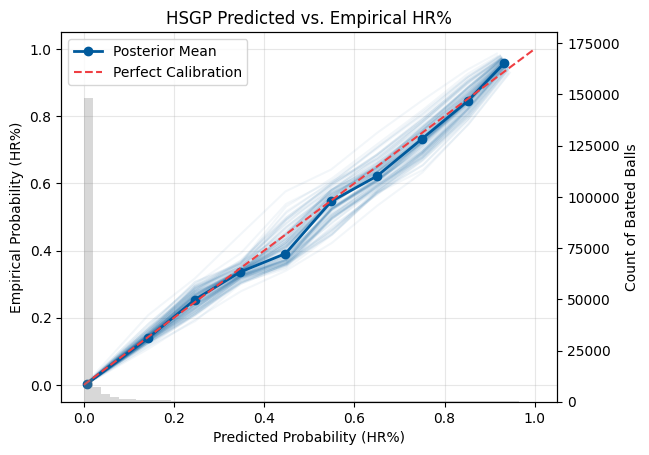

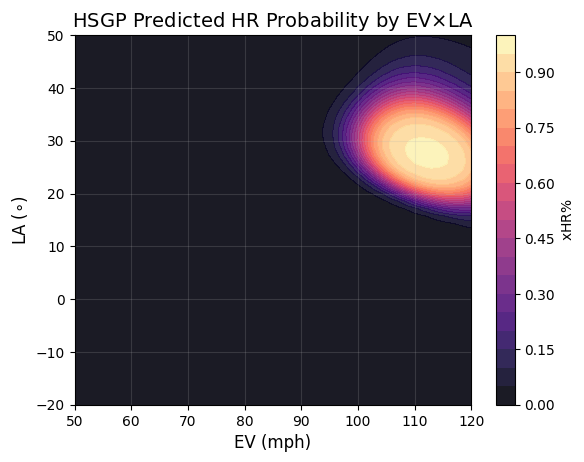

Done
--Training HSGP_matern52_Model--
posterior predictive distrib generated
Test Accuracy: 0.9726659055388674
Test Precision: 0.75748460106002
Test Recall: 0.6201477659200187
Test F1: 0.6819705958215114
Test ROC-AUC: 0.9836363264888448
Test Log-Loss: 0.06627052132963818
Test Brier Score: 0.01982079648807865


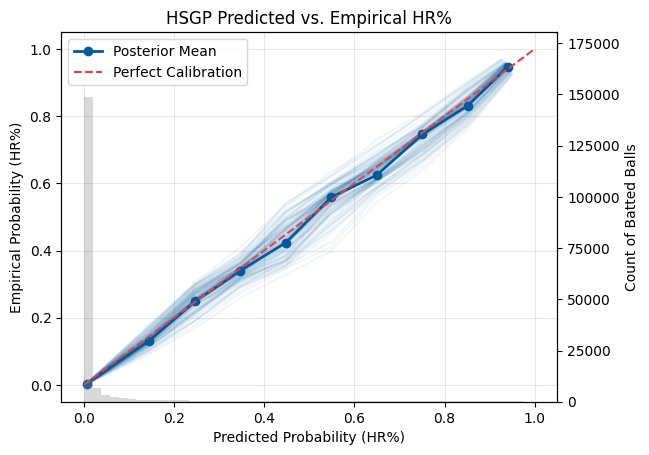

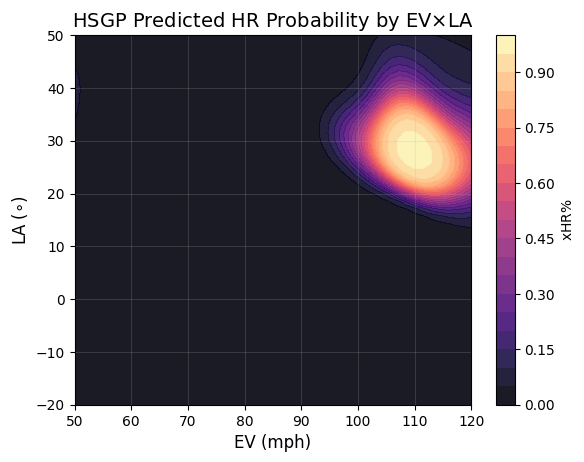

Done


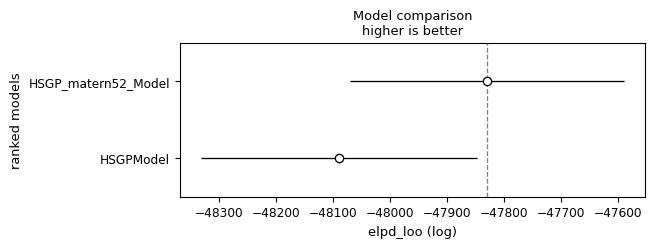

In [13]:
model_idatas = {} ## ArviZ data
for gp in [HSGPModel, HSGP_matern52_Model]:
    print(f"--Training {gp.__name__}--")
    hsgp_m = gp(m=[15, 15], L=[L1 * 1.25, L2 * 1.25])
    hsgp_guide = AutoNormal(hsgp_m.model, init_loc_fn=init_to_median(num_samples=25))
    hsgp_res = fit_svi(seed, hsgp_m.model, hsgp_guide, X=X_train_scaled, y=y_train, num_steps=1_000)
    ## for computational purposes --> we'll decrease the number of generated samples per data point to 500 rather than 2_000 (default)
    post_y_test_hsgp = posterior_predictive_svi(seed, hsgp_m.model, hsgp_guide, hsgp_res.params, X=X_test_scaled, num_samples = 500)
    print('posterior predictive distrib generated')

    mean_f_star = post_y_test_hsgp["f_star"].mean(axis=0)
    probs = jax.nn.sigmoid(mean_f_star) ## log-odds to [0, 1]
    preds = (probs > 0.5).astype(jnp.int64)

    test_results(y_test, probs, preds)

    ## draws 500 samples from our trained parameters
    predictive_guide = Predictive(hsgp_guide, params=hsgp_res.params, num_samples=500)
    posterior_samples = predictive_guide(random.PRNGKey(seed))
    ## calculates the log likelihood of the training data using those 500 samples
    ll = log_likelihood(hsgp_m.model, posterior_samples, X=X_train_scaled, y=y_train)
    clean_ll = jnp.nan_to_num(ll["y"], nan=-100.0, neginf=-100.0) ## so arviz doesn't see any null values --> catches -inf or NaNs
    ## subsampling the log likelihood
    all_bips = clean_ll.shape[1] ## the number of data points
    subset_idx = np.random.choice(all_bips, size=10_000, replace=False) ## randomly picking 10,000 from the training set
    clean_ll_subset = clean_ll[:, subset_idx] ## only keeping 10,000, not all 700,000
    ## adding a "chain" dimension b/c arviz expects it 
    posterior_samples_expanded = {k: v[None, ...] for k, v in posterior_samples.items()}
    log_likelihood_expanded = {"y": clean_ll[None, ...]}
    idata = az.from_dict(posterior=posterior_samples_expanded, log_likelihood=log_likelihood_expanded)
    model_idatas[gp.__name__] = idata

    plot_bayesian_calibration(y_test, post_y_test_hsgp["f_star"])
    plot_decision_boundary(seed, hsgp_m.model, hsgp_guide, hsgp_res.params, X_train_mean, X_train_std)

    ## clears the huge arrays from memory before the loop restarts
    del hsgp_res
    del post_y_test_hsgp
    gc.collect()

    print('Done')

comp_df = az.compare(model_idatas, ic="loo", scale="log")
az.plot_compare(comp_df, insample_dev=False) ## eldp_loo plot model comparison
plt.show()

In [14]:
# model comparison
n_test = len(y_test)

## model 1) the empirical HR% used as the probability for every batted ball
probs_emp = jnp.full(n_test, empirical_hr_prob)
preds_emp = jnp.zeros(n_test, dtype=int)

## model 2) flipping a coin
probs_random = np.random.uniform(0, 1, size=n_test)
preds_random = (probs_random > 0.5).astype(int)

## model 3) logit model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
probs_lr = lr_model.predict_proba(np.array(X_test_scaled))[:, 1] ## prob of a HR (y = 1)
preds_lr = (probs_lr > 0.5).astype(int)

## model 4) xgboost
xgb = XGBClassifier(eval_metric='logloss') ## log loss because we care about probs not just outcomes
xgb.fit(X_train_scaled, y_train)
probs_xgb = xgb.predict_proba(X_test_scaled)[:, 1] ## prob of a HR (y = 1)
preds_xgb = (probs_xgb > 0.5).astype(int)

# model results
print('--Model 1: Empirical HR%--')
test_results(y_test, probs_emp, preds_emp)
print('--Model 2: Random Coin Flip--')
test_results(y_test, probs_random, preds_random)
print('--Model 3: Logit--')
test_results(y_test, probs_lr, preds_lr)
print('--Model 4: XGBoost--')
test_results(y_test, probs_xgb, preds_xgb)

--Model 1: Empirical HR%--
Test Accuracy: 0.952741722735183
Test Precision: 0.0
Test Recall: 0.0
Test F1: 0.0
Test ROC-AUC: 0.5
Test Log-Loss: 0.19036187216315317
Test Brier Score: 0.04502493249625059
--Model 2: Random Coin Flip--
Test Accuracy: 0.4994845760776794
Test Precision: 0.047615359936276844
Test Recall: 0.5047496188577459
Test F1: 0.08702157342445258
Test ROC-AUC: 0.5034222206333688
Test Log-Loss: 0.9999206134143789
Test Brier Score: 0.33355947563635835
--Model 3: Logit--
Test Accuracy: 0.9540164270592018
Test Precision: 0.536346396965866
Test Recall: 0.1990148938665416
Test F1: 0.2903087845351125
Test ROC-AUC: 0.9412931268964065
Test Log-Loss: 0.11211388149555353
Test Brier Score: 0.03370537176302557
--Model 4: XGBoost--
Test Accuracy: 0.9727712072004168
Test Precision: 0.753578445130508
Test Recall: 0.6297642781752082
Test F1: 0.6861304542260269
Test ROC-AUC: 0.9854056935796767
Test Log-Loss: 0.062275658956605
Test Brier Score: 0.019394939103458367


In [29]:
# adding xHRs and HRs to player_primary_pos

batted_ball_xhrs = pd.read_parquet('data/batted_balls_w_xhrs.parquet')
batted_ball_xhrs = batted_ball_xhrs[['game_year', 'batter', 'is_HR', 'xHR']].groupby(['game_year', 'batter'])[['is_HR', 'xHR']].sum().reset_index()

player_primary_pos = player_primary_pos.merge(batted_ball_xhrs, on=['game_year', 'batter'], how='left')
player_primary_pos = player_primary_pos.rename(columns={'is_HR': 'HR'})
player_primary_pos.to_parquet('data/player_primary_pos_w_xhrs.parquet')

In [30]:
player_primary_pos

,game_year,batter,IDfg,name,Age,primary_pos,events,PA,HR,xHR
0,2018,454560,5677,a.j.ellis,37,C,110,183,1,2.312433
1,2018,607223,16246,a.j.reed,25,1B,2,3,0,0.010235
2,2019,607223,16246,a.j.reed,26,1B,24,49,1,1.487031
3,2018,571437,11270,aaron altherr,27,RF,153,285,8,9.337989
4,2019,571437,11270,aaron altherr,28,CF,37,66,1,1.644530
...,...,...,...,...,...,...,...,...,...,...
5118,2021,670097,19562,zack short,26,SS,103,184,6,4.717366
5119,2022,670097,19562,zack short,27,SS,6,13,0,0.311177
5120,2023,670097,19562,zack short,28,2B,157,253,7,9.384552
5121,2024,670097,19562,zack short,29,3B,49,88,0,1.700739
